# Projeto Final (parte B)

Experimentando as ferramentas de aprendizado de máquina do Spark

## Código básico para carregar os dados do INMET

In [20]:
from pyspark.sql import SparkSession
from pyspark.sql.types import StructType, StructField, StringType #, DoubleType, IntegerType
from pyspark.sql import functions as F
import os

In [21]:
os.environ['HADOOP_HOME'] = r'C:\hadoop'
os.environ['PATH'] = r'C:\hadoop\bin;' + os.environ.get('PATH', '')

In [22]:
spark = (
    SparkSession.builder
    .master("local[*]")
    .appName("Meu Projeto")
    .config("spark.driver.memory", "4g")
    #.config("spark.executor.memory", "4g")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")

### Tratamento dos Dados

In [23]:
# verificar se as colunas são as mesmas

nomes_colunas = [
    "Data",
    "Hora UTC",
    "PRECIPITAÇÃO TOTAL, HORÁRIO (mm)",
    "PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)",
    "PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB)",
    "PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB)",
    "RADIACAO GLOBAL (Kj/m²)",
    "TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)",
    "TEMPERATURA DO PONTO DE ORVALHO (°C)",
    "TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C)",
    "TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C)",
    "TEMPERATURA ORVALHO MAX. NA HORA ANT. (AUT) (°C)",
    "TEMPERATURA ORVALHO MIN. NA HORA ANT. (AUT) (°C)",
    "UMIDADE REL. MAX. NA HORA ANT. (AUT) (%)",
    "UMIDADE REL. MIN. NA HORA ANT. (AUT) (%)",
    "UMIDADE RELATIVA DO AR, HORARIA (%)",
    "VENTO, DIREÇÃO HORARIA (gr) (° (gr))",
    "VENTO, RAJADA MAXIMA (m/s)",
    "VENTO, VELOCIDADE HORARIA (m/s)"
]

def limpa_nome_coluna(nome:str):
    nome = nome.replace(' - ', '_')
    nome = nome.replace(', ', '_')
    nome = nome.replace('. ', '_')
    nome = nome.replace(' ', '_')
    nome = nome.replace('.', '_')
    nome = nome.replace(',', '_')
    return(nome)

nomes_colunas_limpo = [limpa_nome_coluna(nome) for nome in nomes_colunas]


In [24]:
for n in nomes_colunas_limpo:
    print(n)

Data
Hora_UTC
PRECIPITAÇÃO_TOTAL_HORÁRIO_(mm)
PRESSAO_ATMOSFERICA_AO_NIVEL_DA_ESTACAO_HORARIA_(mB)
PRESSÃO_ATMOSFERICA_MAX_NA_HORA_ANT_(AUT)_(mB)
PRESSÃO_ATMOSFERICA_MIN_NA_HORA_ANT_(AUT)_(mB)
RADIACAO_GLOBAL_(Kj/m²)
TEMPERATURA_DO_AR_BULBO_SECO_HORARIA_(°C)
TEMPERATURA_DO_PONTO_DE_ORVALHO_(°C)
TEMPERATURA_MÁXIMA_NA_HORA_ANT_(AUT)_(°C)
TEMPERATURA_MÍNIMA_NA_HORA_ANT_(AUT)_(°C)
TEMPERATURA_ORVALHO_MAX_NA_HORA_ANT_(AUT)_(°C)
TEMPERATURA_ORVALHO_MIN_NA_HORA_ANT_(AUT)_(°C)
UMIDADE_REL_MAX_NA_HORA_ANT_(AUT)_(%)
UMIDADE_REL_MIN_NA_HORA_ANT_(AUT)_(%)
UMIDADE_RELATIVA_DO_AR_HORARIA_(%)
VENTO_DIREÇÃO_HORARIA_(gr)_(°_(gr))
VENTO_RAJADA_MAXIMA_(m/s)
VENTO_VELOCIDADE_HORARIA_(m/s)


In [25]:
schema = [StructField(nome, StringType(), True) for nome in nomes_colunas_limpo]
schema = StructType(schema)

In [26]:
sdf = (
    spark.read
    .option('encoding', 'iso-8859-1') # 'latin1'
    .option('sep', ';')
    # .option('decimal', ',') # melhor fazer a leitura como string
    .option('header', False)
    .schema(schema)
    .csv('2024/') # pasta dos arquivos
)

In [27]:
sdf.show()

+-----------------+----------+-------------------------------+----------------------------------------------------+----------------------------------------------+----------------------------------------------+-----------------------+-----------------------------------------+------------------------------------+-----------------------------------------+-----------------------------------------+----------------------------------------------+----------------------------------------------+-------------------------------------+-------------------------------------+----------------------------------+-----------------------------------+-------------------------+------------------------------+
|             Data|  Hora_UTC|PRECIPITAÇÃO_TOTAL_HORÁRIO_(mm)|PRESSAO_ATMOSFERICA_AO_NIVEL_DA_ESTACAO_HORARIA_(mB)|PRESSÃO_ATMOSFERICA_MAX_NA_HORA_ANT_(AUT)_(mB)|PRESSÃO_ATMOSFERICA_MIN_NA_HORA_ANT_(AUT)_(mB)|RADIACAO_GLOBAL_(Kj/m²)|TEMPERATURA_DO_AR_BULBO_SECO_HORARIA_(°C)|TEMPERATURA_DO_PONTO_DE_ORVALH

In [28]:
def inmet_dados_formatados(sdf):
    # para remover as primeiras 8 linhas (metadados)
    # e também a linha com os nomes das colunas
    sdf = (
        sdf
        .filter(~sdf[sdf.columns[0]].contains(":"))
        .filter(~sdf[sdf.columns[0]].contains("Data"))
    )
    # convertendo os númericos para double
    for i in range(2,19):
        nome = sdf.columns[i]
        sdf = sdf.withColumn(
            nome, 
            F.regexp_replace(F.col(nome), ",", ".").cast("double")
        )
    # adicionando coluna temporária com nome do arquivo
    sdf = sdf.withColumn(
        "arquivo", 
        F.element_at(F.split(F.input_file_name(), "/"), -1) # nome.split('/')[-1]
    )
    # criando colunas de região, UF, código WMO e nome da estação
    # WMO = World Meteorological Organization (https://wmo.int/)
    sdf = (
        sdf
        .withColumn("regiao", F.element_at(F.split(F.col("arquivo"), "_"), 2))
        .withColumn("uf", F.element_at(F.split(F.col("arquivo"), "_"), 3))
        .withColumn("codigo_wmo", F.element_at(F.split(F.col("arquivo"), "_"), 4))
        .withColumn("estacao", F.element_at(F.split(F.col("arquivo"), "_"), 5))
    )

    sdf = sdf.dropna()
    sdf = sdf.drop('arquivo')
    return(sdf)

In [29]:
sdf_limpo = inmet_dados_formatados(sdf)

- Formato dos arquivos: CSV com separador ;, encoding iso-8859-1, decimal ,
- Remoção das 8 linhas de metadados (filtro por : e Data)
- Cast de strings para double com substituição de , por .
- `dropna()` para remover linhas com qualquer valor nulo (PCA exige dados completos)
- Extração de região, UF, código WMO e nome da estação do nome do arquivo

In [30]:
sdf_limpo.show()

+----------+--------+-------------------------------+----------------------------------------------------+----------------------------------------------+----------------------------------------------+-----------------------+-----------------------------------------+------------------------------------+-----------------------------------------+-----------------------------------------+----------------------------------------------+----------------------------------------------+-------------------------------------+-------------------------------------+----------------------------------+-----------------------------------+-------------------------+------------------------------+------+---+----------+-------+
|      Data|Hora_UTC|PRECIPITAÇÃO_TOTAL_HORÁRIO_(mm)|PRESSAO_ATMOSFERICA_AO_NIVEL_DA_ESTACAO_HORARIA_(mB)|PRESSÃO_ATMOSFERICA_MAX_NA_HORA_ANT_(AUT)_(mB)|PRESSÃO_ATMOSFERICA_MIN_NA_HORA_ANT_(AUT)_(mB)|RADIACAO_GLOBAL_(Kj/m²)|TEMPERATURA_DO_AR_BULBO_SECO_HORARIA_(°C)|TEMPERATURA_DO_PON

In [31]:
df_limpo = sdf_limpo.limit(5).toPandas()

In [32]:
print(f"Total de registros após limpeza: {sdf_limpo.count()}")
sdf_limpo.describe().toPandas()

Total de registros após limpeza: 1893913


,summary,Data,Hora_UTC,PRECIPITAÇÃO_TOTAL_HORÁRIO_(mm),PRESSAO_ATMOSFERICA_AO_NIVEL_DA_ESTACAO_HORARIA_(mB),PRESSÃO_ATMOSFERICA_MAX_NA_HORA_ANT_(AUT)_(mB),PRESSÃO_ATMOSFERICA_MIN_NA_HORA_ANT_(AUT)_(mB),RADIACAO_GLOBAL_(Kj/m²),TEMPERATURA_DO_AR_BULBO_SECO_HORARIA_(°C),TEMPERATURA_DO_PONTO_DE_ORVALHO_(°C),...,UMIDADE_REL_MAX_NA_HORA_ANT_(AUT)_(%),UMIDADE_REL_MIN_NA_HORA_ANT_(AUT)_(%),UMIDADE_RELATIVA_DO_AR_HORARIA_(%),VENTO_DIREÇÃO_HORARIA_(gr)_(°_(gr)),VENTO_RAJADA_MAXIMA_(m/s),VENTO_VELOCIDADE_HORARIA_(m/s),regiao,uf,codigo_wmo,estacao
0,count,1893913,1893913,1893913,1893913,1893913,1893913,1893913,1893913,1893913,...,1893913,1893913,1893913,1893913,1893913,1893913,1893913,1893913,1893913,1893913
1,mean,None,None,0.18749055526838468,964.6691443587974,965.0013847521006,964.4133898442012,1223.845575219136,25.58511008689417,17.6521104190108,...,69.93478317113828,63.09720773868705,66.00653725910324,154.68233757305643,5.405343856871983,2.1429279486439134,None,None,None,None
2,stddev,None,None,1.518824273917679,38.41228375046851,38.42613183144823,38.399077653524046,1125.5825240700449,5.597563028547481,5.270957000713208,...,21.24059854256752,21.96743804123758,21.64052611206495,100.75473500840185,2.8896813801335157,1.615235427543826,None,None,None,None
3,min,2024/01/01,0000 UTC,0.0,814.2,814.6,813.6,0.0,-5.5,-30.6,...,7.0,7.0,7.0,1.0,0.0,0.0,CO,AC,A001,AFONSO%20CLAUDIO
4,max,2024/12/31,2300 UTC,88.4,1048.9,1049.6,1048.4,8208.9,43.2,34.8,...,100.0,100.0,100.0,360.0,42.3,24.1,SE,TO,F501,ZE%20DOCA


In [33]:
sdf_limpo.columns

['Data',
 'Hora_UTC',
 'PRECIPITAÇÃO_TOTAL_HORÁRIO_(mm)',
 'PRESSAO_ATMOSFERICA_AO_NIVEL_DA_ESTACAO_HORARIA_(mB)',
 'PRESSÃO_ATMOSFERICA_MAX_NA_HORA_ANT_(AUT)_(mB)',
 'PRESSÃO_ATMOSFERICA_MIN_NA_HORA_ANT_(AUT)_(mB)',
 'RADIACAO_GLOBAL_(Kj/m²)',
 'TEMPERATURA_DO_AR_BULBO_SECO_HORARIA_(°C)',
 'TEMPERATURA_DO_PONTO_DE_ORVALHO_(°C)',
 'TEMPERATURA_MÁXIMA_NA_HORA_ANT_(AUT)_(°C)',
 'TEMPERATURA_MÍNIMA_NA_HORA_ANT_(AUT)_(°C)',
 'TEMPERATURA_ORVALHO_MAX_NA_HORA_ANT_(AUT)_(°C)',
 'TEMPERATURA_ORVALHO_MIN_NA_HORA_ANT_(AUT)_(°C)',
 'UMIDADE_REL_MAX_NA_HORA_ANT_(AUT)_(%)',
 'UMIDADE_REL_MIN_NA_HORA_ANT_(AUT)_(%)',
 'UMIDADE_RELATIVA_DO_AR_HORARIA_(%)',
 'VENTO_DIREÇÃO_HORARIA_(gr)_(°_(gr))',
 'VENTO_RAJADA_MAXIMA_(m/s)',
 'VENTO_VELOCIDADE_HORARIA_(m/s)',
 'regiao',
 'uf',
 'codigo_wmo',
 'estacao']

In [34]:
df_limpo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 23 columns):
 #   Column                                                Non-Null Count  Dtype  
---  ------                                                --------------  -----  
 0   Data                                                  5 non-null      object 
 1   Hora_UTC                                              5 non-null      object 
 2   PRECIPITAÇÃO_TOTAL_HORÁRIO_(mm)                       5 non-null      float64
 3   PRESSAO_ATMOSFERICA_AO_NIVEL_DA_ESTACAO_HORARIA_(mB)  5 non-null      float64
 4   PRESSÃO_ATMOSFERICA_MAX_NA_HORA_ANT_(AUT)_(mB)        5 non-null      float64
 5   PRESSÃO_ATMOSFERICA_MIN_NA_HORA_ANT_(AUT)_(mB)        5 non-null      float64
 6   RADIACAO_GLOBAL_(Kj/m²)                               5 non-null      float64
 7   TEMPERATURA_DO_AR_BULBO_SECO_HORARIA_(°C)             5 non-null      float64
 8   TEMPERATURA_DO_PONTO_DE_ORVALHO_(°C)                  5 non-null

### Esboço da rotina de PCA do Spark (via MLlib)

---

Referências:
- https://spark.apache.org/docs/latest/ml-guide.html
- https://spark.apache.org/docs/latest/api/python/reference/api/pyspark.ml.feature.PCA.html
- https://spark.apache.org/docs/latest/api/python/reference/api/pyspark.ml.linalg.DenseVector.html

In [35]:
import numpy as np
from pyspark.ml.feature import VectorAssembler, StandardScaler, PCA

In [36]:
# a rotina de PCA do Spark precisa de uma coluna do tipo DenseVector
# https://spark.apache.org/docs/latest/api/python/reference/api/pyspark.ml.feature.VectorAssembler.html
agrupador = VectorAssembler(
    inputCols=[
 'PRECIPITAÇÃO_TOTAL_HORÁRIO_(mm)',
 'PRESSAO_ATMOSFERICA_AO_NIVEL_DA_ESTACAO_HORARIA_(mB)',
 'PRESSÃO_ATMOSFERICA_MAX_NA_HORA_ANT_(AUT)_(mB)',
 'PRESSÃO_ATMOSFERICA_MIN_NA_HORA_ANT_(AUT)_(mB)',
 'RADIACAO_GLOBAL_(Kj/m²)',
 'TEMPERATURA_DO_AR_BULBO_SECO_HORARIA_(°C)',
 'TEMPERATURA_DO_PONTO_DE_ORVALHO_(°C)',
 'TEMPERATURA_MÁXIMA_NA_HORA_ANT_(AUT)_(°C)',
 'TEMPERATURA_MÍNIMA_NA_HORA_ANT_(AUT)_(°C)',
 'TEMPERATURA_ORVALHO_MAX_NA_HORA_ANT_(AUT)_(°C)',
 'TEMPERATURA_ORVALHO_MIN_NA_HORA_ANT_(AUT)_(°C)',
 'UMIDADE_REL_MAX_NA_HORA_ANT_(AUT)_(%)',
 'UMIDADE_REL_MIN_NA_HORA_ANT_(AUT)_(%)',
 'UMIDADE_RELATIVA_DO_AR_HORARIA_(%)',
 'VENTO_DIREÇÃO_HORARIA_(gr)_(°_(gr))',
 'VENTO_RAJADA_MAXIMA_(m/s)',
 'VENTO_VELOCIDADE_HORARIA_(m/s)'], 
    outputCol="vetor_agrupado"
)
df_agrupado = agrupador.transform(sdf_limpo)

print(df_agrupado.dtypes)
df_agrupado.toPandas()

[('Data', 'string'), ('Hora_UTC', 'string'), ('PRECIPITAÇÃO_TOTAL_HORÁRIO_(mm)', 'double'), ('PRESSAO_ATMOSFERICA_AO_NIVEL_DA_ESTACAO_HORARIA_(mB)', 'double'), ('PRESSÃO_ATMOSFERICA_MAX_NA_HORA_ANT_(AUT)_(mB)', 'double'), ('PRESSÃO_ATMOSFERICA_MIN_NA_HORA_ANT_(AUT)_(mB)', 'double'), ('RADIACAO_GLOBAL_(Kj/m²)', 'double'), ('TEMPERATURA_DO_AR_BULBO_SECO_HORARIA_(°C)', 'double'), ('TEMPERATURA_DO_PONTO_DE_ORVALHO_(°C)', 'double'), ('TEMPERATURA_MÁXIMA_NA_HORA_ANT_(AUT)_(°C)', 'double'), ('TEMPERATURA_MÍNIMA_NA_HORA_ANT_(AUT)_(°C)', 'double'), ('TEMPERATURA_ORVALHO_MAX_NA_HORA_ANT_(AUT)_(°C)', 'double'), ('TEMPERATURA_ORVALHO_MIN_NA_HORA_ANT_(AUT)_(°C)', 'double'), ('UMIDADE_REL_MAX_NA_HORA_ANT_(AUT)_(%)', 'double'), ('UMIDADE_REL_MIN_NA_HORA_ANT_(AUT)_(%)', 'double'), ('UMIDADE_RELATIVA_DO_AR_HORARIA_(%)', 'double'), ('VENTO_DIREÇÃO_HORARIA_(gr)_(°_(gr))', 'double'), ('VENTO_RAJADA_MAXIMA_(m/s)', 'double'), ('VENTO_VELOCIDADE_HORARIA_(m/s)', 'double'), ('regiao', 'string'), ('uf', 'string

,Data,Hora_UTC,PRECIPITAÇÃO_TOTAL_HORÁRIO_(mm),PRESSAO_ATMOSFERICA_AO_NIVEL_DA_ESTACAO_HORARIA_(mB),PRESSÃO_ATMOSFERICA_MAX_NA_HORA_ANT_(AUT)_(mB),PRESSÃO_ATMOSFERICA_MIN_NA_HORA_ANT_(AUT)_(mB),RADIACAO_GLOBAL_(Kj/m²),TEMPERATURA_DO_AR_BULBO_SECO_HORARIA_(°C),TEMPERATURA_DO_PONTO_DE_ORVALHO_(°C),TEMPERATURA_MÁXIMA_NA_HORA_ANT_(AUT)_(°C),...,UMIDADE_REL_MIN_NA_HORA_ANT_(AUT)_(%),UMIDADE_RELATIVA_DO_AR_HORARIA_(%),VENTO_DIREÇÃO_HORARIA_(gr)_(°_(gr)),VENTO_RAJADA_MAXIMA_(m/s),VENTO_VELOCIDADE_HORARIA_(m/s),regiao,uf,codigo_wmo,estacao,vetor_agrupado
0,2024/01/01,0000 UTC,0.0,1009.8,1009.8,1009.2,0.0,27.4,24.1,28.2,...,80.0,82.0,193.0,4.7,1.3,N,PA,A201,BELEM,"[0.0, 1009.8, 1009.8, 1009.2, 0.0, 27.4, 24.1,..."
1,2024/01/01,0100 UTC,0.0,1010.8,1010.8,1009.8,0.0,27.2,24.2,27.4,...,82.0,84.0,242.0,4.2,0.4,N,PA,A201,BELEM,"[0.0, 1010.8, 1010.8, 1009.8, 0.0, 27.2, 24.2,..."
2,2024/01/01,0200 UTC,0.0,1010.7,1010.8,1010.3,0.0,26.4,24.7,27.2,...,84.0,90.0,242.0,1.6,0.0,N,PA,A201,BELEM,"[0.0, 1010.7, 1010.8, 1010.3, 0.0, 26.4, 24.7,..."
3,2024/01/01,0300 UTC,0.0,1010.2,1010.8,1010.2,0.0,26.9,24.8,26.9,...,88.0,88.0,248.0,1.8,0.3,N,PA,A201,BELEM,"[0.0, 1010.2, 1010.8, 1010.2, 0.0, 26.9, 24.8,..."
4,2024/01/01,0400 UTC,0.0,1009.7,1010.2,1009.7,0.0,26.9,24.8,27.1,...,88.0,89.0,236.0,3.0,0.0,N,PA,A201,BELEM,"[0.0, 1009.7, 1010.2, 1009.7, 0.0, 26.9, 24.8,..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1893908,2024/01/03,1400 UTC,0.0,978.2,978.7,978.2,1971.3,30.9,21.1,30.9,...,56.0,56.0,95.0,2.3,0.0,NE,BA,A436,QUEIMADAS,"[0.0, 978.2, 978.7, 978.2, 1971.3, 30.9, 21.1,..."
1893909,2024/01/03,1500 UTC,0.0,977.1,978.2,977.1,3024.4,31.3,19.7,32.7,...,47.0,50.0,56.0,5.4,0.4,NE,BA,A436,QUEIMADAS,"[0.0, 977.1, 978.2, 977.1, 3024.4, 31.3, 19.7,..."
1893910,2024/01/03,1600 UTC,0.0,976.4,977.2,976.4,2153.8,31.8,19.9,32.0,...,48.0,50.0,63.0,8.8,4.1,NE,BA,A436,QUEIMADAS,"[0.0, 976.4, 977.2, 976.4, 2153.8, 31.8, 19.9,..."
1893911,2024/01/03,1700 UTC,0.0,975.0,976.4,975.0,2195.3,30.4,21.0,34.4,...,42.0,57.0,269.0,7.4,3.9,NE,BA,A436,QUEIMADAS,"[0.0, 975.0, 976.4, 975.0, 2195.3, 30.4, 21.0,..."


In [37]:
# rotina de normalização
# subtrai a média (centraliza em zero)
# dividide pelo desvio padrão (normaliza o desvio padrão para 1)
config_normalizacao = StandardScaler(
    inputCol="vetor_agrupado", 
    outputCol="vetor_normalizado", 
    withMean=True,
    withStd=True
)
modelo_normalizacao = config_normalizacao.fit(df_agrupado)
df_normalizado = modelo_normalizacao.transform(df_agrupado)
df_normalizado.toPandas()

,Data,Hora_UTC,PRECIPITAÇÃO_TOTAL_HORÁRIO_(mm),PRESSAO_ATMOSFERICA_AO_NIVEL_DA_ESTACAO_HORARIA_(mB),PRESSÃO_ATMOSFERICA_MAX_NA_HORA_ANT_(AUT)_(mB),PRESSÃO_ATMOSFERICA_MIN_NA_HORA_ANT_(AUT)_(mB),RADIACAO_GLOBAL_(Kj/m²),TEMPERATURA_DO_AR_BULBO_SECO_HORARIA_(°C),TEMPERATURA_DO_PONTO_DE_ORVALHO_(°C),TEMPERATURA_MÁXIMA_NA_HORA_ANT_(AUT)_(°C),...,UMIDADE_RELATIVA_DO_AR_HORARIA_(%),VENTO_DIREÇÃO_HORARIA_(gr)_(°_(gr)),VENTO_RAJADA_MAXIMA_(m/s),VENTO_VELOCIDADE_HORARIA_(m/s),regiao,uf,codigo_wmo,estacao,vetor_agrupado,vetor_normalizado
0,2024/01/01,0000 UTC,0.0,1009.8,1009.8,1009.2,0.0,27.4,24.1,28.2,...,82.0,193.0,4.7,1.3,N,PA,A201,BELEM,"[0.0, 1009.8, 1009.8, 1009.2, 0.0, 27.4, 24.1,...","[-0.12344453435996403, 1.1749068588158076, 1.1..."
1,2024/01/01,0100 UTC,0.0,1010.8,1010.8,1009.8,0.0,27.2,24.2,27.4,...,84.0,242.0,4.2,0.4,N,PA,A201,BELEM,"[0.0, 1010.8, 1010.8, 1009.8, 0.0, 27.2, 24.2,...","[-0.12344453435996403, 1.2009401976950094, 1.1..."
2,2024/01/01,0200 UTC,0.0,1010.7,1010.8,1010.3,0.0,26.4,24.7,27.2,...,90.0,242.0,1.6,0.0,N,PA,A201,BELEM,"[0.0, 1010.7, 1010.8, 1010.3, 0.0, 26.4, 24.7,...","[-0.12344453435996403, 1.1983368638070915, 1.1..."
3,2024/01/01,0300 UTC,0.0,1010.2,1010.8,1010.2,0.0,26.9,24.8,26.9,...,88.0,248.0,1.8,0.3,N,PA,A201,BELEM,"[0.0, 1010.2, 1010.8, 1010.2, 0.0, 26.9, 24.8,...","[-0.12344453435996403, 1.1853201943674907, 1.1..."
4,2024/01/01,0400 UTC,0.0,1009.7,1010.2,1009.7,0.0,26.9,24.8,27.1,...,89.0,236.0,3.0,0.0,N,PA,A201,BELEM,"[0.0, 1009.7, 1010.2, 1009.7, 0.0, 26.9, 24.8,...","[-0.12344453435996403, 1.17230352492789, 1.176..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1893908,2024/01/03,1400 UTC,0.0,978.2,978.7,978.2,1971.3,30.9,21.1,30.9,...,56.0,95.0,2.3,0.0,NE,BA,A436,QUEIMADAS,"[0.0, 978.2, 978.7, 978.2, 1971.3, 30.9, 21.1,...","[-0.12344453435996403, 0.35225335023303594, 0...."
1893909,2024/01/03,1500 UTC,0.0,977.1,978.2,977.1,3024.4,31.3,19.7,32.7,...,50.0,56.0,5.4,0.4,NE,BA,A436,QUEIMADAS,"[0.0, 977.1, 978.2, 977.1, 3024.4, 31.3, 19.7,...","[-0.12344453435996403, 0.32361667746591344, 0...."
1893910,2024/01/03,1600 UTC,0.0,976.4,977.2,976.4,2153.8,31.8,19.9,32.0,...,50.0,63.0,8.8,4.1,NE,BA,A436,QUEIMADAS,"[0.0, 976.4, 977.2, 976.4, 2153.8, 31.8, 19.9,...","[-0.12344453435996403, 0.30539334025047105, 0...."
1893911,2024/01/03,1700 UTC,0.0,975.0,976.4,975.0,2195.3,30.4,21.0,34.4,...,57.0,269.0,7.4,3.9,NE,BA,A436,QUEIMADAS,"[0.0, 975.0, 976.4, 975.0, 2195.3, 30.4, 21.0,...","[-0.12344453435996403, 0.26894666581958926, 0...."


Rodamos inicialmente o PCA para k=17 e observamos a variância acumulada para escolher o valor ótimo de k. Obtivemos os seguintes resultados:

| k | Variância Explicada | Variância Acumulada |
|---|---|---|
| 1 | 32.93% | 32.93% |
| 2 | 29.01% | 61.94% |
| 3 | 11.42% | 73.36% |
| 4 | 10.00% | 83.36% |
| 5 | 5.90% | 89.26% |
| 6 | 5.58% | 94.84% |
| 7 | 3.44% | 98.28% |
| 8 | 0.88% | 99.16% |
| 9 | 0.40% | 99.56% |
| 10 | 0.20% | 99.76% |
| 11 | 0.13% | 99.89% |
| 12 | 0.04% | 99.93% |
| 13 | 0.04% | 99.97% |
| 14 | 0.02% | 99.99% |
| 15 | 0.01% | 100.00% |
| 16 | 0.00% | 100.00% |
| 17 | 0.00% | 100.00% |

In [38]:
# PCA é uma decomposição matricial da forma T = X.W
pca = PCA(
    k=4, 
    inputCol="vetor_normalizado", 
    outputCol="pontuacoes"
)
modelo_pca = pca.fit(df_normalizado)
df_pca = modelo_pca.transform(df_normalizado)

In [39]:
# confirma a tabela de variância que está no markdown acima
var_exp = modelo_pca.explainedVariance.toArray()
for i, v in enumerate(var_exp):
    print(f"PC{i+1}: {v*100:.2f}%  (acumulada: {sum(var_exp[:i+1])*100:.2f}%)")

PC1: 32.93%  (acumulada: 32.93%)
PC2: 29.01%  (acumulada: 61.94%)
PC3: 11.42%  (acumulada: 73.36%)
PC4: 10.01%  (acumulada: 83.36%)


In [40]:
# matrizes X e T
df_pca.select("vetor_normalizado", "pontuacoes").toPandas()

,vetor_normalizado,pontuacoes
0,"[-0.12344453435996403, 1.1749068588158076, 1.1...","[-2.198350518707901, 2.6577447218654378, -0.28..."
1,"[-0.12344453435996403, 1.2009401976950094, 1.1...","[-2.3853809161491935, 2.5494923326089953, -0.3..."
2,"[-0.12344453435996403, 1.1983368638070915, 1.1...","[-3.0040341681493814, 2.537671546515377, -0.25..."
3,"[-0.12344453435996403, 1.1853201943674907, 1.1...","[-3.0285386467579714, 2.5578289771318077, -0.2..."
4,"[-0.12344453435996403, 1.17230352492789, 1.176...","[-2.9167733103113704, 2.596347192813083, -0.18..."
...,...,...
1893908,"[-0.12344453435996403, 0.35225335023303594, 0....","[0.4443432247636989, 1.9944215021867597, 0.533..."
1893909,"[-0.12344453435996403, 0.32361667746591344, 0....","[1.5816264795080792, 2.158105944991389, 0.5868..."
1893910,"[-0.12344453435996403, 0.30539334025047105, 0....","[1.9413413421134216, 1.8666775332923848, 0.310..."
1893911,"[-0.12344453435996403, 0.26894666581958926, 0....","[1.7202891111487357, 1.929622437573724, 0.6541..."


In [41]:
# matriz W
modelo_pca.pc.toArray()

array([[-0.06026115, -0.00919734,  0.03587494,  0.18515726],
       [-0.08263991,  0.33436424, -0.45730118,  0.01655804],
       [-0.08099055,  0.33519871, -0.45635223,  0.01746983],
       [-0.08131174,  0.33494312, -0.45678771,  0.01656324],
       [ 0.25183647,  0.10808175,  0.15247913,  0.11526594],
       [ 0.25801375,  0.33112907,  0.17231407, -0.07071418],
       [-0.23236581,  0.32552763,  0.28224912,  0.07172748],
       [ 0.26316132,  0.32386545,  0.17312949, -0.06579898],
       [ 0.24748781,  0.33408732,  0.16831161, -0.06733191],
       [-0.21194424,  0.3353855 ,  0.29594263,  0.0764314 ],
       [-0.24019935,  0.32094236,  0.27241312,  0.08090771],
       [-0.40993962, -0.02209022,  0.07597366,  0.10396464],
       [-0.40973616, -0.02837237,  0.04643517,  0.09562628],
       [-0.41291696, -0.02525724,  0.06083145,  0.10098761],
       [-0.02618342, -0.03166368,  0.07725165, -0.12776823],
       [ 0.18191712, -0.01395328, -0.01230713,  0.64975516],
       [ 0.13801224, -0.

## Visualização

In [42]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

In [43]:
# amostra de 10% para visualização
amostra = df_pca.select("pontuacoes", "regiao").sample(fraction=0.1, seed=42)
amostra_pd = amostra.toPandas()
amostra_pd["PC1"] = amostra_pd["pontuacoes"].apply(lambda x: float(x[0]))
amostra_pd["PC2"] = amostra_pd["pontuacoes"].apply(lambda x: float(x[1]))
amostra_pd["PC3"] = amostra_pd["pontuacoes"].apply(lambda x: float(x[2]))
amostra_pd["PC4"] = amostra_pd["pontuacoes"].apply(lambda x: float(x[3]))

### W

As colunas da matriz W funcionam como "pesos" para criar cada componente principal.

- Cada vetor é uma lista que diz o "peso" de cada variável original do componente.
- Valor alto: Significa que aquela variável é muito importante para formar aquele componente.
- Sinal (positivo ou negativo): Indica se a variável ajuda a aumentar ou a diminuir o valor do componente.

In [51]:
var_pct = {"PC1": 32.93, "PC2": 29.01, "PC3": 11.42, "PC4": 10.01}

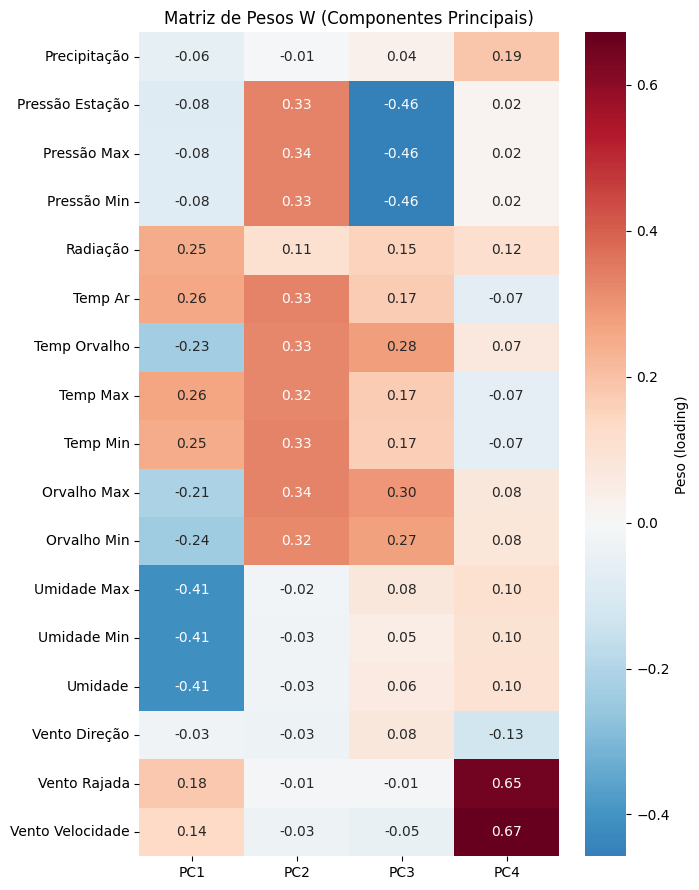

In [52]:
nomes = [
    'Precipitação', 'Pressão Estação', 'Pressão Max', 'Pressão Min',
    'Radiação', 'Temp Ar', 'Temp Orvalho', 'Temp Max', 'Temp Min',
    'Orvalho Max', 'Orvalho Min', 'Umidade Max', 'Umidade Min', 'Umidade',
    'Vento Direção', 'Vento Rajada', 'Vento Velocidade'
]
W = modelo_pca.pc.toArray()
W_df = pd.DataFrame(W, index=nomes, columns=[f'PC{i+1}' for i in range(4)])

fig, ax = plt.subplots(figsize=(7, 9))
sns.heatmap(W_df, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax,
            cbar_kws={'label': 'Peso (loading)'})
ax.set_title("Matriz de Pesos W (Componentes Principais)")
plt.tight_layout()
plt.show()

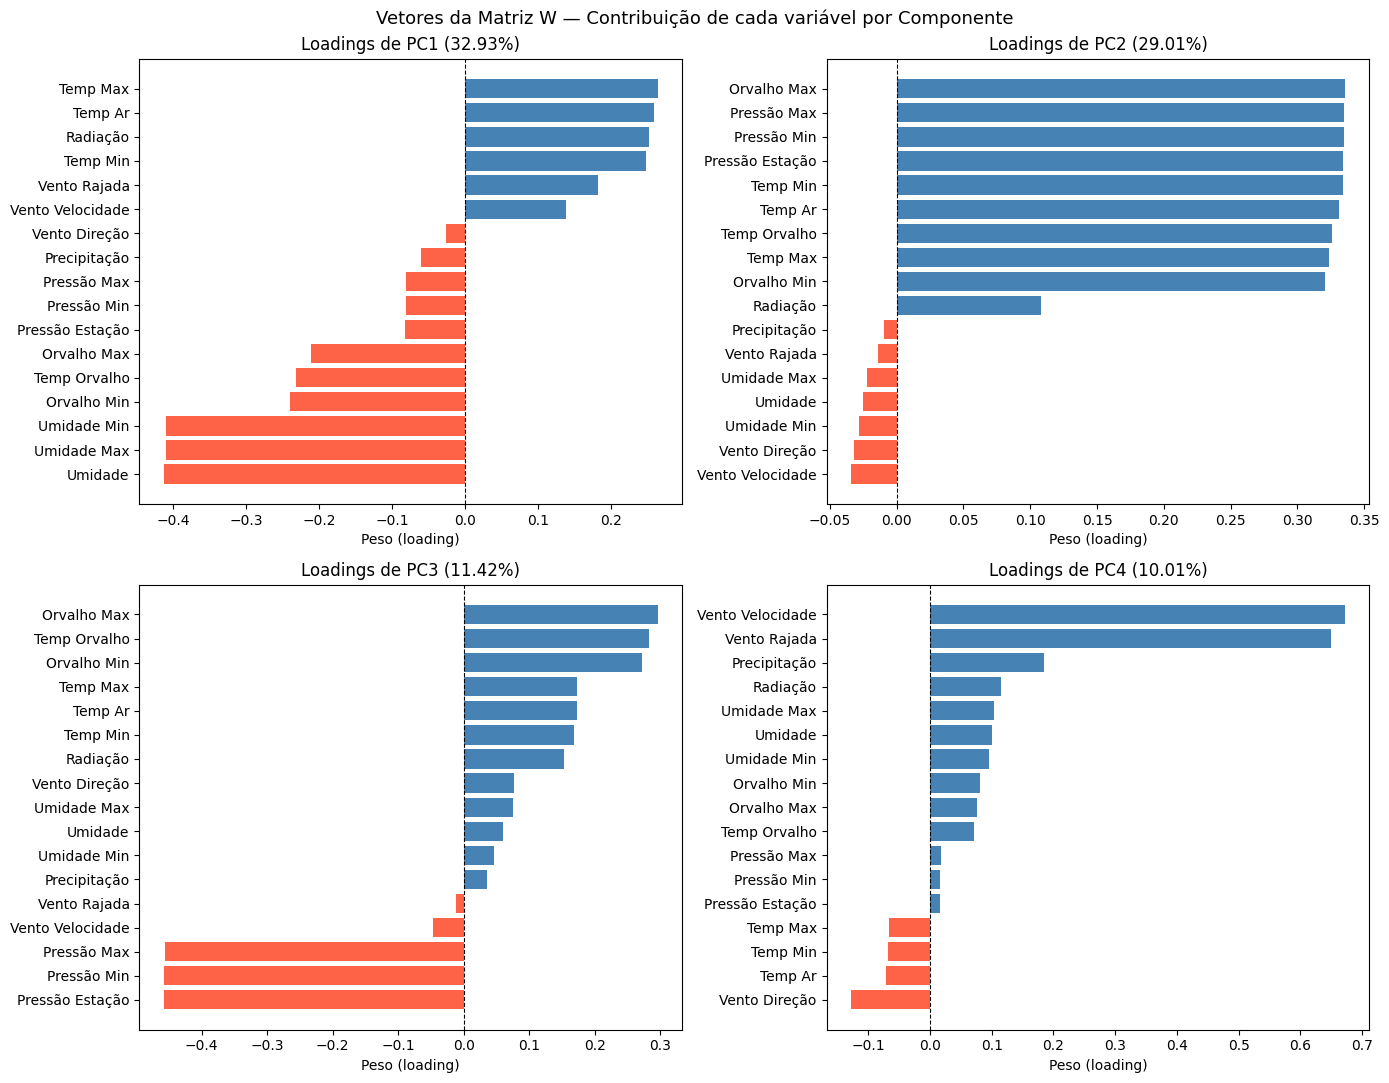

In [53]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
for ax, pc in zip(axes.flat, W_df.columns):
    vals = W_df[pc].sort_values()
    colors = ["tomato" if v < 0 else "steelblue" for v in vals]
    ax.barh(vals.index, vals.values, color=colors)
    ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set(title=f"Loadings de {pc} ({var_pct[pc]}%)", xlabel="Peso (loading)")

plt.suptitle("Vetores da Matriz W — Contribuição de cada variável por Componente", fontsize=13)
plt.tight_layout()
plt.show()

**PC1 (32.93%):** 
| Variáveis com peso alto negativo | Variáveis com peso alto positivo |
|---|---|
| Umidade (~−0,41) | Temp Ar / Max / Min (~+0,25 a +0,26) |
| Temp Orvalho / Orvalho Max / Min (~−0,21 a −0,24) | Radiação (+0,25) |

Separa condições úmidas e frescas (scores negativos) de condições quentes e secas (scores positivos).

**PC2 (29.01%):** 
| Variáveis com peso alto positivo |
|---|
| Pressão (~+0,33), Temp Ar/Max/Min (~+0,32 a +0,33), Orvalho Max/Min (~+0,32 a +0,34) |

Representa o nível geral de calor e condições atmosféricas. Score alto indica estação a baixa altitude com clima quente e pressão elevada. Score baixo indica estações de maior altitude ou latitude sul, onde pressão e temperatura são menores.

**PC3 (11.42%):**
| Variáveis com peso alto negativo | Variáveis com peso moderado positivo |
|---|---|
| Pressão Estação / Max / Min (~−0,46) | Temp Orvalho / Orvalho Max / Min (~+0,27 a +0,30) |

Capta variação de pressão atmosférica, provavelmente relacionada à altitude das estações. Score alto em PC3 significa baixa pressão com alto ponto de orvalho.

**PC4 (10.00%):**
| Variáveis dominantes |
|---|
| Vento Velocidade (+0,67), Vento Rajada (+0,65) |

Componente de intensidade do vento. Scores altos indicam observações com vento forte e rajadas intensas

### T

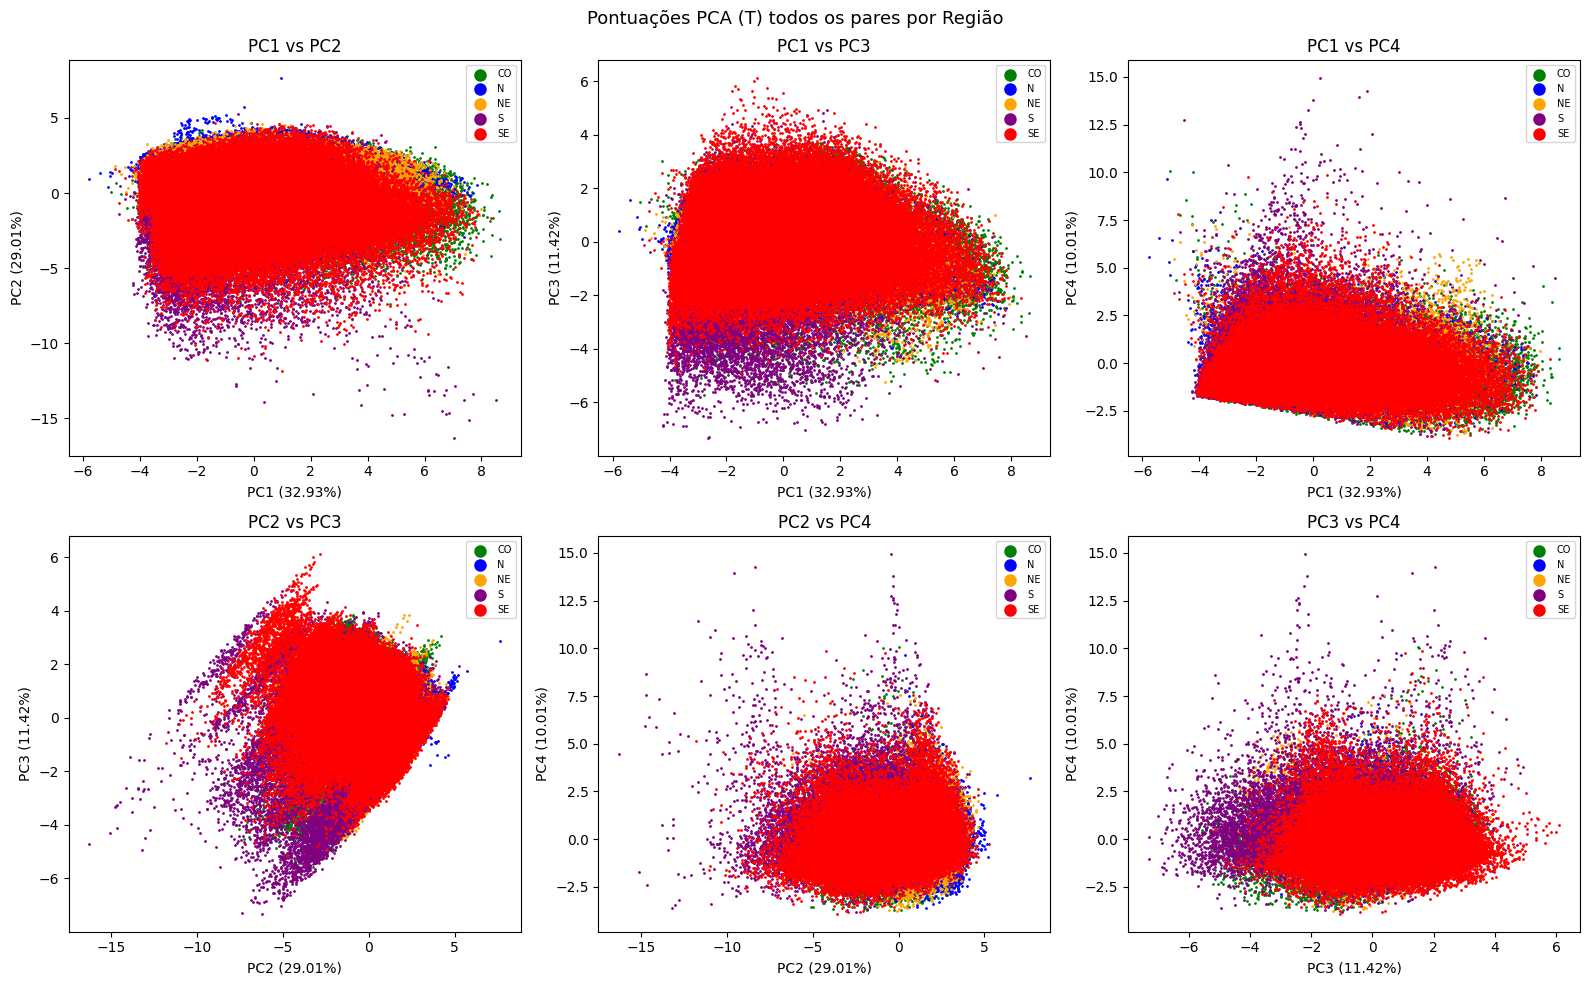

In [54]:
pares = [("PC1", "PC2"), ("PC1", "PC3"), ("PC1", "PC4"),
         ("PC2", "PC3"), ("PC2", "PC4"), ("PC3", "PC4")]
cores = {"N": "blue", "NE": "orange", "CO": "green", "SE": "red", "S": "purple"}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, (px, py) in zip(axes.flat, pares):
    for regiao, grupo in amostra_pd.groupby("regiao"):
        ax.scatter(grupo[px], grupo[py], s=1,
                   label=regiao, color=cores.get(regiao, "gray"))
    ax.set(xlabel=f"{px} ({var_pct[px]}%)", ylabel=f"{py} ({var_pct[py]}%)", title=f"{px} vs {py}")
    ax.legend(markerscale=8, fontsize=7)

plt.suptitle("Pontuações PCA (T) todos os pares por Região", fontsize=13)
plt.tight_layout()
plt.show()

**PC1 × PC2**
A ponta esquerda (PC1 negativo = úmido) é estreita e alta, enquanto a direita (PC1 positivo = seco/quente) se abre muito em PC2. Isso indica que regiões úmidas têm temperatura relativamente constante, mas regiões secas apresentam grande variação de nível térmico.


**PC1 X PC4**
A grande massa de dados se concentra em PC4 baixo (vento fraco), mas os eventos de vento forte (PC4 alto) ocorrem em sua grande maioria com PC1 negativo (condições úmidas).

**PC2 X PC3**
Temperatura alta (PC2 alto) tende a ocorrer junto com pressão alta (PC3 baixo = pressão alta)

---

- SE (Sudeste) aparece com mais frequência do que qualquer outra região, mostrando que tem mais estações de monitoramento.
- As regiões se sobrepõem bastante, o clima brasileiro varia de forma contínua, não há fronteiras rígidas entre regiões climáticas.

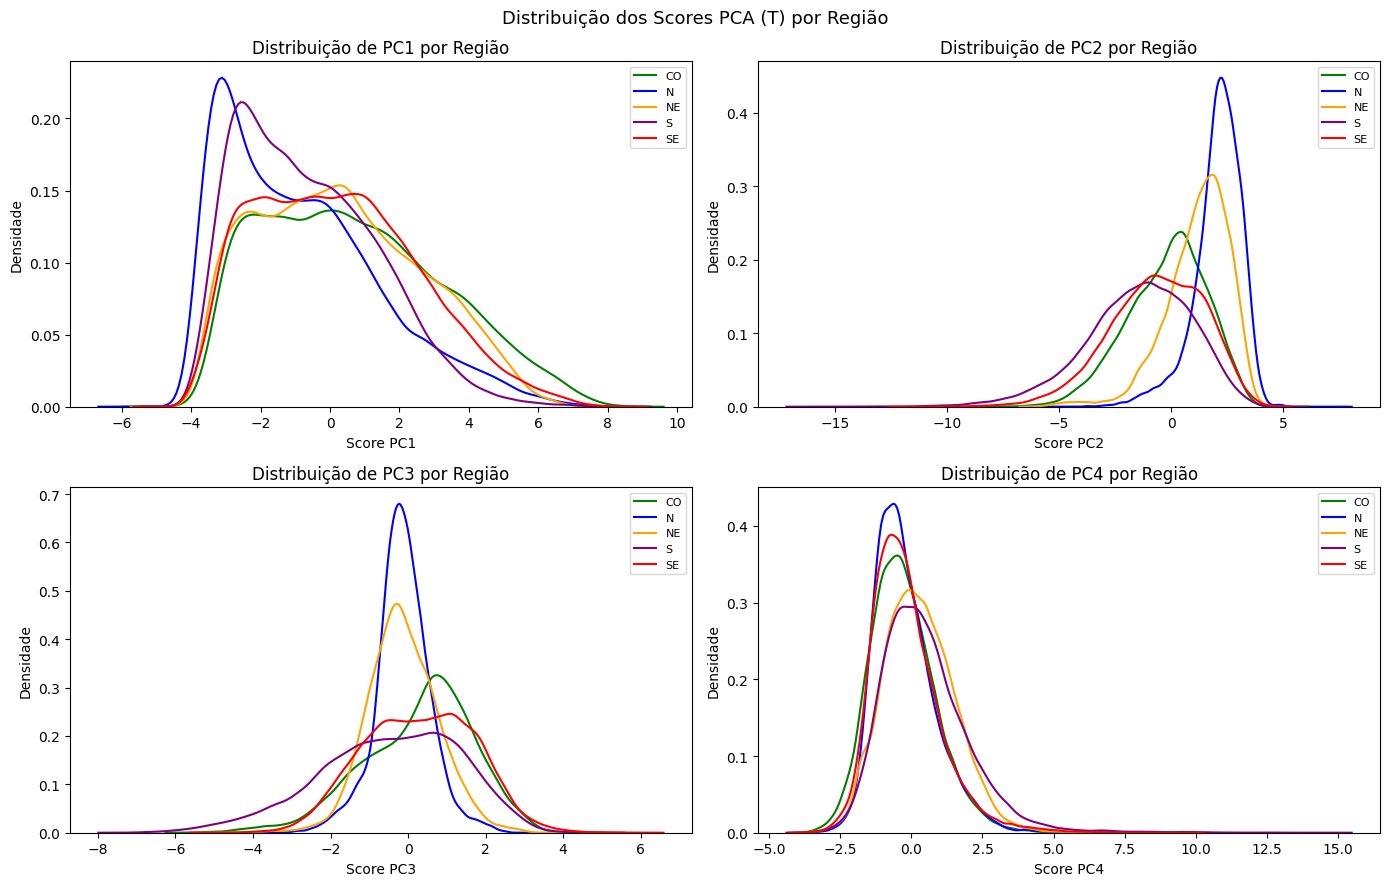

In [55]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, pc in zip(axes.flat, ["PC1", "PC2", "PC3", "PC4"]):
    for regiao, grupo in amostra_pd.groupby("regiao"):
        sns.kdeplot(grupo[pc], ax=ax, label=regiao, color=cores.get(regiao, "gray"))
    ax.set(xlabel=f"Score {pc}", ylabel="Densidade", title=f"Distribuição de {pc} por Região")
    ax.legend(fontsize=8)

plt.suptitle("Distribuição dos Scores PCA (T) por Região", fontsize=13)
plt.tight_layout()
plt.show()

**PC1**
- Norte e Sul tem picos à esquerda, indicando que são as regiões mais úmidas/frescas do dataset;

**PC2**
- Norte tem um pico altíssimo com PC2 positivo, indicando um clima uniforme, temperatura e pressão estáveis o ano todo.
- Sudeste esta mais espalhado no PC2, tem uma grande diversidade climática na região.

**PC3**
- Norte tem um alto pico em PC3 ~0, mostrando que a pressão atmosférica é quase constante.
- Sul e Sudeste tem distribuições mais espalhadas com cauda pra esquerda, mostrando mais variabilidade de pressão.

**PC4**
- Todas as regiões tem curvaturas praticamente idênticas, concentradas em PC4 ~ 1 a 0.
- A itensidade do vento não diferencia as regiões brasileiras.